<a href="https://colab.research.google.com/github/adwait-ops/GW-ODW-2025/blob/main/Challenge_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q lalsuite gwpy pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 103.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

In [3]:
from google.colab import files

uploaded = files.upload()

Saving challenge3.gwf to challenge3.gwf


/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Scanning for mass: 10 Solar Masses...
Scanning for mass: 25 Solar Masses...
Scanning for mass: 40 Solar Masses...


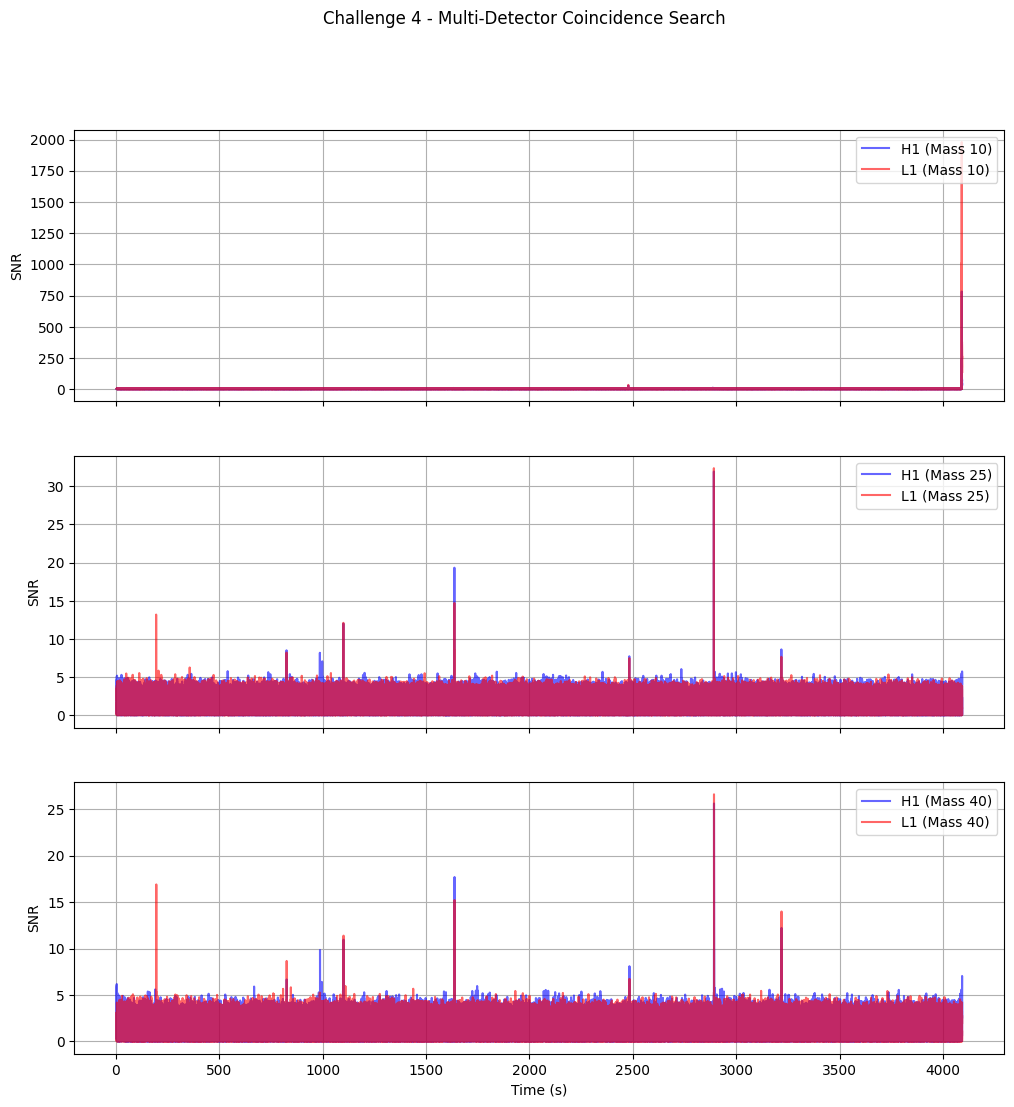

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc import frame
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation

#load data
h1_strain = frame.read_frame('challenge3.gwf', 'H1:CHALLENGE3')
l1_strain = frame.read_frame('challenge3.gwf', 'L1:CHALLENGE3')

#calculate snr of specific mass
def get_snr(strain, mass):
    hp, _ = get_td_waveform(approximant="SEOBNRv4_opt",
                             mass1=mass, mass2=mass,
                             delta_t=strain.delta_t, f_lower=20)
    hp.resize(len(strain))

#4second psd
    psd = strain.psd(4)
    psd = interpolate(psd, strain.delta_f)
    psd = inverse_spectrum_truncation(psd, int(4 * strain.sample_rate), low_frequency_cutoff=20)

    snr = matched_filter(hp, strain, psd=psd, low_frequency_cutoff=20)
    return snr.crop(4, 4)

test_masses = [10, 25, 40]
fig, axes = plt.subplots(len(test_masses), 1, figsize=(12, 12), sharex=True)

for i, m in enumerate(test_masses):
    print(f"Scanning for mass: {m} Solar Masses...")
    snr_h1 = get_snr(h1_strain, m)
    snr_l1 = get_snr(l1_strain, m)

    axes[i].plot(snr_h1.sample_times, np.absolute(snr_h1), label=f'H1 (Mass {m})', color='blue', alpha=0.6)
    axes[i].plot(snr_l1.sample_times, np.absolute(snr_l1), label=f'L1 (Mass {m})', color='red', alpha=0.6)
    axes[i].set_ylabel("SNR")
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

plt.xlabel("Time (s)")
plt.suptitle("Challenge 4 - Multi-Detector Coincidence Search")
plt.show()